# Foreign-object detection in lentils with Dinomaly and Cuvis.AI

This tutorial runs **trained Dinomaly anomaly-detection pipelines** on a hyperspectral
CU3S video of lentils moving under a conveyor belt. The goal is to find foreign objects
such as stones, stems, aluminium shards, and flies in otherwise normal lentils.

We compare three ways of converting the hyperspectral cube into the 3-channel input that
Dinomaly expects:

1. **RGB**: visible-light false/true color style input.
2. **CIR**: color-infrared input using near-infrared information.
3. **Custom selector**: three fixed bands that performed well for the frozen AdaCLIP selector.

**Example channel views.** These static PNGs are the same physical frame rendered as the
three model inputs (per-channel min-max normalization, scaled to `uint8 [0, 255]`).

| RGB view | CIR view | Custom selector view |
|---|---|---|
| ![rgb](https://huggingface.co/datasets/cubert-gmbh/XMR_Demo_Industrial_Foreign_Object_Detection_Lentils/resolve/main/assets/rgb_minmax_u8_frame27.png) | ![cir](https://huggingface.co/datasets/cubert-gmbh/XMR_Demo_Industrial_Foreign_Object_Detection_Lentils/resolve/main/assets/cir_minmax_u8_frame27.png) | ![custom](https://huggingface.co/datasets/cubert-gmbh/XMR_Demo_Industrial_Foreign_Object_Detection_Lentils/resolve/main/assets/custom_minmax_u8_frame27.png) |

The visible-light RGB compresses most of the spectral information into a narrow
visual band and many foreign materials stay near-isoluminant with lentils. CIR
adds a near-infrared component that reveals organic-vs-mineral contrast, and the
custom selector picks three bands chosen by a separate selector experiment for
maximum task-aligned separability.

The tutorial follows this flow:

```
CU3S session + JSON GT
    -> RGB / CIR / Custom 3-channel view
    -> trained Dinomaly detector
    -> anomaly heatmap
    -> image gate + pixel quantile threshold
    -> final mask and overlay video
```

> **Prerequisites**
>
> 1. A working `cuvis-ai` development environment (`uv sync` from the repo root).
> 2. Internet access on first run: the pipeline YAML, weights, and a sample
>    CU3S video are pulled from
>    [HuggingFace](https://huggingface.co/cubert-gmbh/XMR_Demo_Industrial_Foreign_Object_Detection_Lentils)
>    via `huggingface_hub.hf_hub_download` and cached under `~/.cache/huggingface`.
> 3. The `cuvis-ai-dinomaly` plugin (v0.1.3) is fetched on demand by
>    `NodeRegistry.load_plugins(...)`; the DINOv2 backbone the plugin depends on
>    is auto-downloaded by `cuvis-ai-dinomaly`.
> 4. `graphviz dot` is optional but recommended for pipeline graph rendering.
> 5. Video export uses `ToVideoNode` first and falls back to an OpenCV writer if needed.

In [1]:
# Colab bootstrap. The tutorial fetches its assets from HuggingFace, so it works
# in Colab as long as `cuvis-ai` and `cuvis-ai-dinomaly` are installed.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Colab. Make sure cuvis-ai is installed (e.g. `pip install cuvis-ai`)")
    print("and that the runtime has internet access for the HuggingFace downloads.")


In [2]:
%matplotlib inline
from __future__ import annotations

from pathlib import Path
import sys
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, Markdown, Video, display
from loguru import logger

# Robust import whether Jupyter's cwd is the repo root or this notebook folder.
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "utils.py").is_file():
    USE_CASES_DIR = NOTEBOOK_DIR
else:
    USE_CASES_DIR = NOTEBOOK_DIR / "notebooks" / "use_cases"
if str(USE_CASES_DIR) not in sys.path:
    sys.path.insert(0, str(USE_CASES_DIR))

from utils import (
    METHOD_TITLES,
    assert_paths_exist,
    export_overlay_video,
    load_pipeline_for_inference,
    load_reference_metrics,
    make_predict_loader,
    render_input_triplet,
    render_method_triplet,
    resolve_default_config,
    run_method_on_frame_subset,
    summarize_subset,
)


def _format_table_value(value: Any) -> str:
    if isinstance(value, float):
        return f"{value:.4f}"
    return str(value)


def _markdown_table(rows: list[dict[str, Any]], columns: Iterable[str]) -> str:
    columns = list(columns)
    if not rows:
        return "_No rows available._"
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        values = [_format_table_value(row.get(col, "")) for col in columns]
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, sep, *body])


def display_records_table(rows: list[dict[str, Any]], columns: Iterable[str], *, title: str | None = None) -> None:
    markdown = _markdown_table(rows, columns)
    if title:
        markdown = f"**{title}**\n\n{markdown}"
    display(Markdown(markdown))


device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

W0506 14:30:51.918000 19412 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


2026-05-06 14:30:52.399 | INFO     | __main__:<module>:69 - Using device cuda


## 1 · Dataset and objective

The lentils video is a CU3S session: each frame stores a hyperspectral cube
`[H, W, C]`, not just RGB pixels. The matching JSON contains object masks.

In this use case, class `0` is normal/background. Any non-zero label is treated as
foreign material for anomaly-detection evaluation.

Typical classes in this sequence:

- `1` stone
- `2` stem_k
- `3` alu_shard
- `4` fly

The detector never sees these labels during inference. It only outputs anomaly scores;
we use GT masks afterwards to explain and evaluate predictions.

The CU3S file, JSON annotations, the pipeline YAML, and the trained `.pt` weight
are all fetched from HuggingFace on first run and cached locally.


In [3]:
config = resolve_default_config()
assert_paths_exist(config)

cu3s_file_path = config["cu3s_path"]
annotation_json_path = config["annotation_json_path"]
comparison_json_path = config["method_comparison_json"]
output_dir = USE_CASES_DIR / "outputs" / "Auto_003+01"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"CU3S:           {cu3s_file_path}")
print(f"Annotations:    {annotation_json_path}")
print(f"Methods on HF:  {[m.name for m in config['methods']]}")
print(f"Output dir:     {output_dir}")


dinomaly_multifile_rgb_two_stage.yaml: 0.00B [00:00, ?B/s]

D:\cuvis-ai\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anish.raj\.cache\huggingface\hub\models--cubert-gmbh--XMR_Demo_Industrial_Foreign_Object_Detection_Lentils. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


dinomaly_rgb_full_pipeline/dinomaly_mult(…):   0%|          | 0.00/592M [00:00<?, ?B/s]

dinomaly_multifile_cir_two_stage.yaml: 0.00B [00:00, ?B/s]

dinomaly_cir_full_pipeline/dinomaly_mult(…):   0%|          | 0.00/592M [00:00<?, ?B/s]

dinomaly_multifile_custom_two_stage.yaml: 0.00B [00:00, ?B/s]

dinomaly_custom_selector_full_pipeline/d(…):   0%|          | 0.00/592M [00:00<?, ?B/s]

CU3S:           C:\Users\anish.raj\.cache\huggingface\hub\datasets--cubert-gmbh--XMR_Demo_Industrial_Foreign_Object_Detection_Lentils\snapshots\9bcd26b608d3fe9770c6cd9b1f0aab9a2e62293d\measurements\cu3s\2026_04_15_13_32_55\Auto_003+01.cu3s
Annotations:    C:\Users\anish.raj\.cache\huggingface\hub\datasets--cubert-gmbh--XMR_Demo_Industrial_Foreign_Object_Detection_Lentils\snapshots\9bcd26b608d3fe9770c6cd9b1f0aab9a2e62293d\measurements\cu3s\2026_04_15_13_32_55\Auto_003+01.json
Methods on HF:  ['dinomaly_rgb', 'dinomaly_cir', 'dinomaly_concrete']
Output dir:     D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01


## 2 · Why compare RGB, CIR, and Custom selector?

Dinomaly consumes a 3-channel image, but the camera measures many spectral bands.
The key question is therefore: **which three channels should represent the cube?**

For lentils + foreign-object detection three properties matter:

- **Visible vs near-infrared contrast.** Visible light separates colours, but many
  inorganic foreign objects (stones, aluminium) reflect similarly to lentils once
  averaged over the visible range. Near-infrared bands often expose moisture and
  surface-structure differences that visible bands suppress.
- **Per-pixel band selection.** A *fixed* RGB or CIR triple is reproducible and
  cheap, but a learned selector that optimises against an anomaly-detection loss
  can locate the three bands that maximally separate normal lentils from outliers.
- **Network compatibility.** Dinomaly was trained on natural-image RGB; the
  selector still has to produce three channels in roughly the same dynamic range,
  otherwise the pre-trained backbone is poorly conditioned.

The three methods we compare keep the architecture fixed and only change the
hyperspectral-to-3-channel projection:

- **RGB** (`(650, 550, 450)` nm) — intuitive and presentation-friendly, but
  many foreign materials are not strongly separated in visible colour.
- **CIR** (visible-green, visible-red, NIR) — injects near-infrared contrast.
- **Custom selector** (`(542, 902, 886)` nm) — fixed bands picked from a finetuned
  AdaCLIP selector experiment as the indices `(14, 59, 57)` of the camera's
  spectral grid. They place two channels in the NIR and one in green, which
  empirically separates lentils from foreign material best on this video.

A reference metrics table is provided when available; if the comparison JSON
isn't present (e.g., on a fresh HF-only setup), this cell prints a notice and
the rest of the tutorial continues without it.


In [4]:
if comparison_json_path is not None:
    ref_metrics = load_reference_metrics(comparison_json_path)
    metrics_rows = [
        {"method": METHOD_TITLES.get(method_name, method_name), **metrics}
        for method_name, metrics in ref_metrics.items()
    ]
    display_records_table(
        metrics_rows,
        ["method", "pixel_auroc", "image_auroc", "pixel_iou", "image_f1"],
        title="Reference metrics",
    )
else:
    print("Reference-metrics JSON not provided; showing metrics for inferenced preview frames below.")

Reference-metrics JSON not provided; showing metrics for inferenced preview frames below.


## 3 · Knobs

A single cell with the values you may want to change while reading. All
downstream cells consume these names — re-run from here after you edit.


In [5]:
# Frame to drill down on. Frame 27 in this sequence has multiple object masks.
PREVIEW_FRAME_ID = 27

# A small subset for the cross-method comparison panel.
FRAME_INDICES = [18, 24, PREVIEW_FRAME_ID, 30]

# Class IDs treated as "normal" for evaluation. Anything else counts as anomaly.
NORMAL_CLASS_IDS = {0}

# Output video frame rate (the CU3S session was captured at a slow conveyor speed).
VIDEO_FPS = 4.0

# Set False to skip the (slower) full-sweep video export and only run preview frames.
RUN_VIDEO_EXPORT_IF_MISSING = True


## 4 · Build / load the Dinomaly pipelines

Each method is a standalone YAML + PT pair fetched from HuggingFace. We render
one of the loaded pipeline graphs for transparency. The pipeline is conceptually:

```
LentilsAnomalyDataNode  -> MinMaxNormalizer  -> rgb_selector
                                                    |
                                                    v
                                          DinomalyDetector  -> TwoStageBinaryDecider
```

What each node does:

- **`LentilsAnomalyDataNode`** — passthrough that turns the multi-class GT mask
  into a binary anomaly mask (used at training/eval; inference reads the cube
  directly from the dataloader's batch).
- **`MinMaxNormalizer`** — running per-cube min-max so the selector sees data in
  a consistent dynamic range.
- **`rgb_selector` (`FixedWavelengthSelector`)** — picks the three target
  wavelengths for this method and emits a 3-channel image.
- **`DinomalyDetector`** — pre-trained DINOv2 backbone + Dinomaly anomaly head;
  produces a per-pixel anomaly score map.
- **`TwoStageBinaryDecider`** — first gates the frame on the mean of the top-k
  per-pixel scores (image-level threshold), then quantile-thresholds the score
  map per pixel.

If a method's HF subfolder is missing (RGB and CIR are not yet uploaded as full
pipelines), `resolve_default_config()` skips it with a warning and the cells
below iterate only over the methods that loaded.


2026-05-06 14:34:57.484 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_git_plugin:519 - Using cached plugin 'dinomaly' at C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3


2026-05-06 14:34:57.501 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 9 dependencies from C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3\pyproject.toml


2026-05-06 14:34:57.501 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 9 dependencies for plugin 'dinomaly'...


2026-05-06 14:34:57.501 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai>=0.1.0, cuvis-ai-core>=0.1.0, anomalib==2.1.0, kornia==0.6.12, numpy>=1.20.0, opencv-python>=4.8.0, tqdm>=4.66.0, defusedxml>=0.7.1, open-clip-torch>=2.24.0


2026-05-06 14:34:57.667 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:285 - ✓ Plugin 'dinomaly' dependencies installed successfully


...

2026-05-06 14:34:57.799 | DEBUG    | cuvis_ai_core.utils.node_registry:load_plugin:417 - Registered plugin node 'DinomalyTrainLossBridge' from 'dinomaly'


2026-05-06 14:34:57.800 | INFO     | cuvis_ai_core.utils.node_registry:load_plugin:422 - Loaded plugin 'dinomaly' with 2 nodes


2026-05-06 14:34:57.801 | INFO     | cuvis_ai_core.utils.node_registry:load_plugins:327 - Loaded 1 plugins from D:\cuvis-ai\configs\plugins\dinomaly.yaml


D:\cuvis-ai\.venv\Lib\site-packages\cuvis_ai_core\pipeline\factory.py:232: MissingNodeMetadataWarning: Node class cuvis_ai_dinomaly.node.dinomaly_detector.DinomalyDetector is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  pipeline._assign_counter_and_add_node(node)


2026-05-06 14:35:02.032 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_concrete_pipeline_graph.png


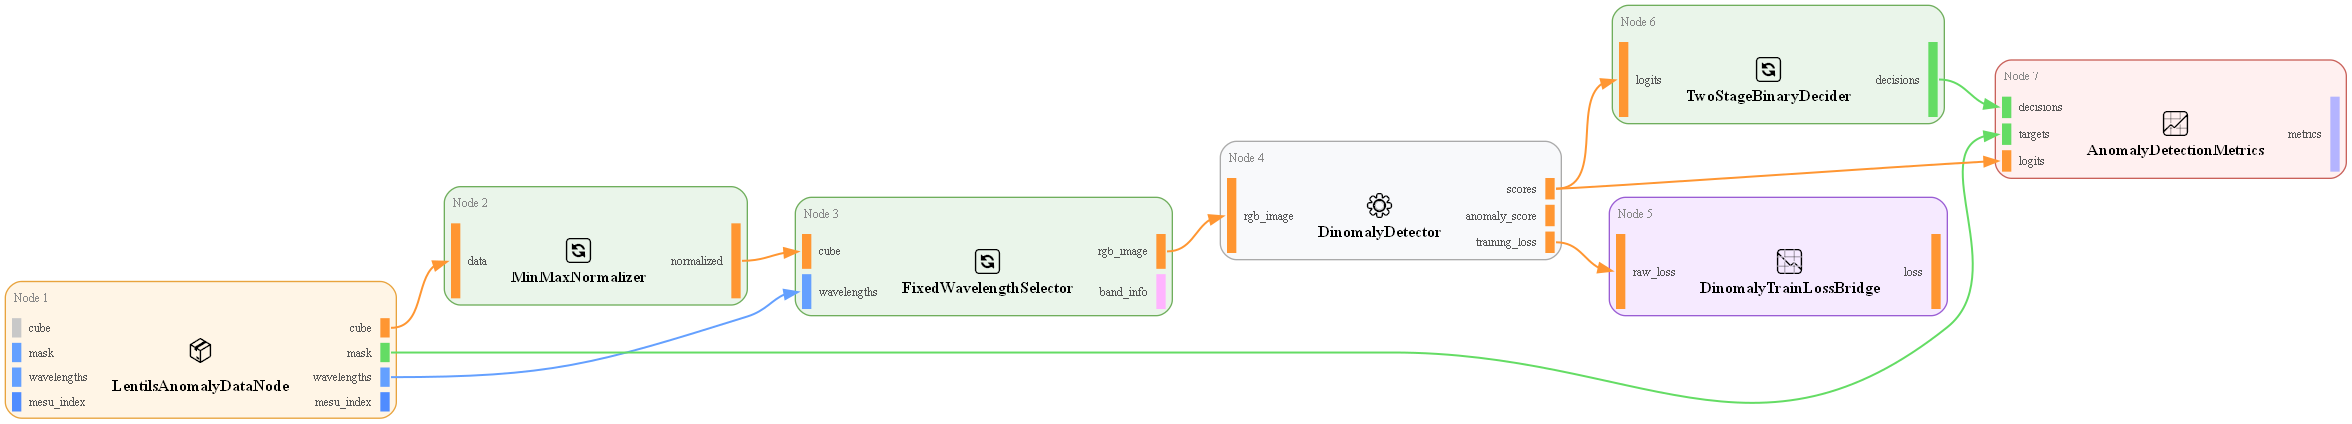

In [6]:
# Load one pipeline and render its graph for explanation. The custom selector is
# the only method that ships a complete HF pipeline today; iterate from the end
# so we always pick the most-feature-rich available method.
graph_method = config["methods"][-1]
graph_pipeline = load_pipeline_for_inference(
    yaml_path=graph_method.yaml_path,
    pt_path=graph_method.pt_path,
    plugins_manifest=config["plugins_manifest"],
    device=str(device),
)

graph_png = graph_pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{graph_method.name}_pipeline_graph.png"),
)
display(Image(str(graph_png)))


## 5 · Sanity-check on a frame with objects

Before running every frame, inspect a frame that actually contains annotations.
Frame `27` (set in §3) has multiple object masks, so it is a useful visual
anchor. The cells below run live inference on the small `FRAME_INDICES` subset.


In [7]:
dm, loader = make_predict_loader(
    cu3s_file_path,
    annotation_json_path,
    processing_mode="Reflectance",
    batch_size=1,
)
print(f"Total CU3S measurements: {len(dm.predict_ds)}")
print(f"Preview frame:           {PREVIEW_FRAME_ID}")
print(f"Frames for comparison:   {FRAME_INDICES}")


2026-05-06 14:35:11.614 | INFO     | cuvis_ai_core.data.datasets:__init__:95 - Loaded cu3s dataset from C:\Users\anish.raj\.cache\huggingface\hub\datasets--cubert-gmbh--XMR_Demo_Industrial_Foreign_Object_Detection_Lentils\snapshots\9bcd26b608d3fe9770c6cd9b1f0aab9a2e62293d\measurements\cu3s\2026_04_15_13_32_55\Auto_003+01.cu3s with 69 measurements: [0..68]


2026-05-06 14:35:11.649 | INFO     | cuvis_ai_core.data.datasets:__init__:118 - Category map: {0: 'Unlabeled', 1: 'stone', 2: 'stem_k', 3: 'alu_shard', 4: 'fly'}


Total CU3S measurements: 69
Preview frame:           27
Frames for comparison:   [18, 24, 27, 30]


In [8]:
preview_results: dict[str, list[dict]] = {}

for method in config["methods"]:
    print(f"Running preview inference for {method.title} ...")
    pipe = load_pipeline_for_inference(
        yaml_path=method.yaml_path,
        pt_path=method.pt_path,
        plugins_manifest=config["plugins_manifest"],
        device=str(device),
    )
    rows = run_method_on_frame_subset(
        pipeline=pipe,
        loader=loader,
        frame_indices=set(FRAME_INDICES),
        image_threshold=method.image_threshold,
        quantile=method.quantile,
        top_k_fraction=method.top_k_fraction,
        device=device,
        normal_class_ids=NORMAL_CLASS_IDS,
    )
    preview_results[method.name] = rows

counts = {k: len(v) for k, v in preview_results.items()}
print(counts)
assert all(v > 0 for v in counts.values()), (
    "No preview rows were produced for at least one method."
)

preview_metric_rows = summarize_subset(preview_results)
display_records_table(
    preview_metric_rows,
    ["method", "n_frames", "mean_iou", "mean_image_score", "mean_pixel_threshold"],
    title="Preview-frame metrics",
)

2026-05-06 14:35:11.747 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_git_plugin:519 - Using cached plugin 'dinomaly' at C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3


2026-05-06 14:35:11.747 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 9 dependencies from C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3\pyproject.toml


2026-05-06 14:35:11.747 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 9 dependencies for plugin 'dinomaly'...


2026-05-06 14:35:11.747 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai>=0.1.0, cuvis-ai-core>=0.1.0, anomalib==2.1.0, kornia==0.6.12, numpy>=1.20.0, opencv-python>=4.8.0, tqdm>=4.66.0, defusedxml>=0.7.1, open-clip-torch>=2.24.0


2026-05-06 14:35:11.808 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:285 - ✓ Plugin 'dinomaly' dependencies installed successfully


...

2026-05-06 14:35:59.970 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:111 - TwoStageDecider input: shape=torch.Size([1, 1000, 1080, 1]), device=cuda:0, dtype=torch.float32, min=0.046255, max=0.237356, mean=0.080070


2026-05-06 14:35:59.973 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:138 - TwoStageDecider[batch=0]: k=1080, topk_min=0.199137, topk_max=0.237356, image_score=0.216080


2026-05-06 14:35:59.975 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:156 - TwoStageDecider: image_score=0.216080 >= threshold=0.151000, applying quantile thresholding (q=0.995)


{'dinomaly_rgb': 4, 'dinomaly_cir': 4, 'dinomaly_concrete': 4}


**Preview-frame metrics**

| method | n_frames | mean_iou | mean_image_score | mean_pixel_threshold |
| --- | --- | --- | --- | --- |
| Dinomaly RGB | 4 | 0.0335 | 0.1395 | 0.1191 |
| Dinomaly CIR | 4 | 0.1647 | 0.1452 | 0.1140 |
| Dinomaly Custom Selector | 4 | 0.2217 | 0.2110 | 0.1489 |

## 6 · What goes into the detectors?

The next figure shows the **same physical frame** rendered as each method's
3-channel input. This is where the channel-choice argument is easiest to see:
the visible-RGB view washes out small foreign objects, while CIR and the
custom selector keep them as distinct intensity differences.


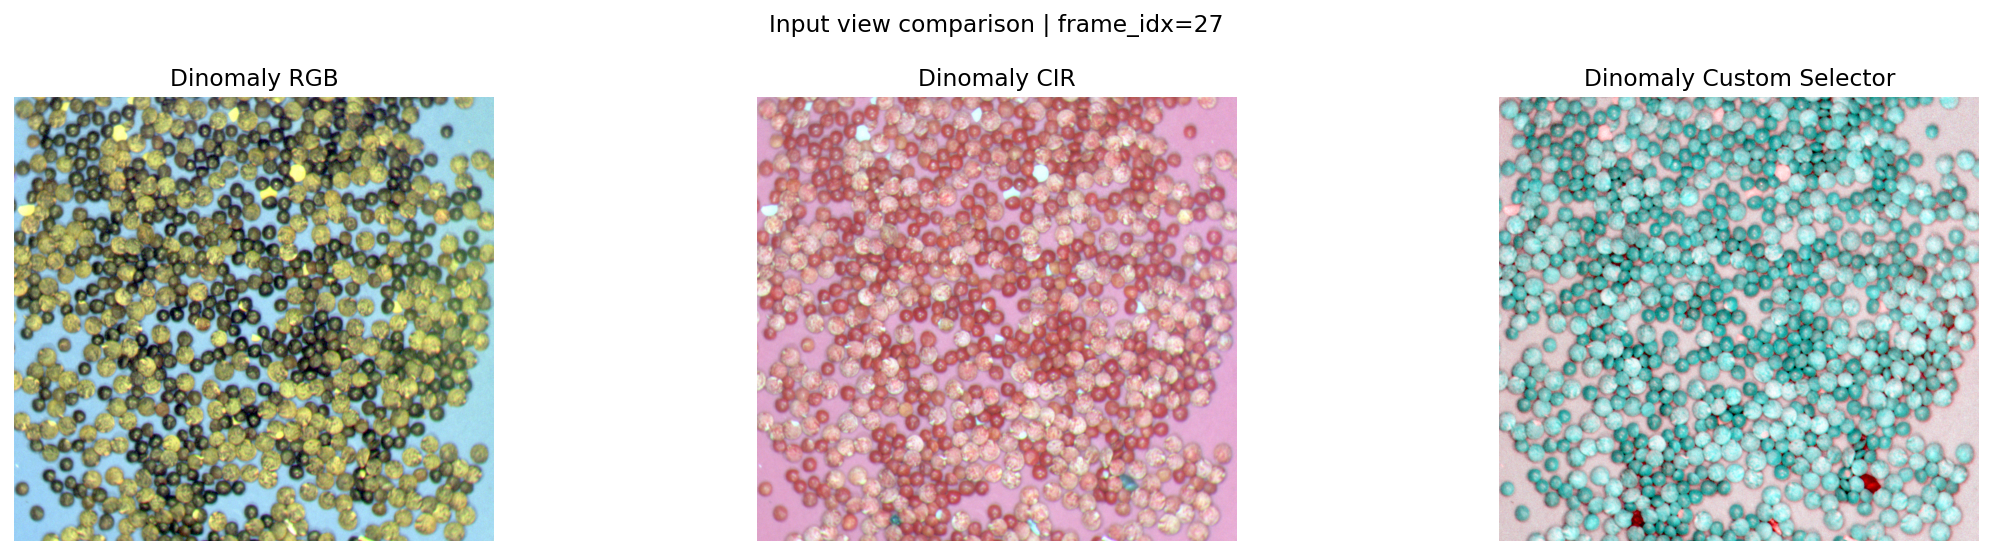

In [9]:
render_input_triplet(preview_results, frame_idx=PREVIEW_FRAME_ID)
plt.show()


## 7 · Predictions, heatmaps, and overlays

For each available method, we display:

- the 3-channel input view,
- the dense anomaly heatmap,
- the thresholded predicted mask,
- a GT-vs-prediction overlay.

Overlay colours:

- green: GT object pixels
- red: predicted object pixels
- yellow: overlap


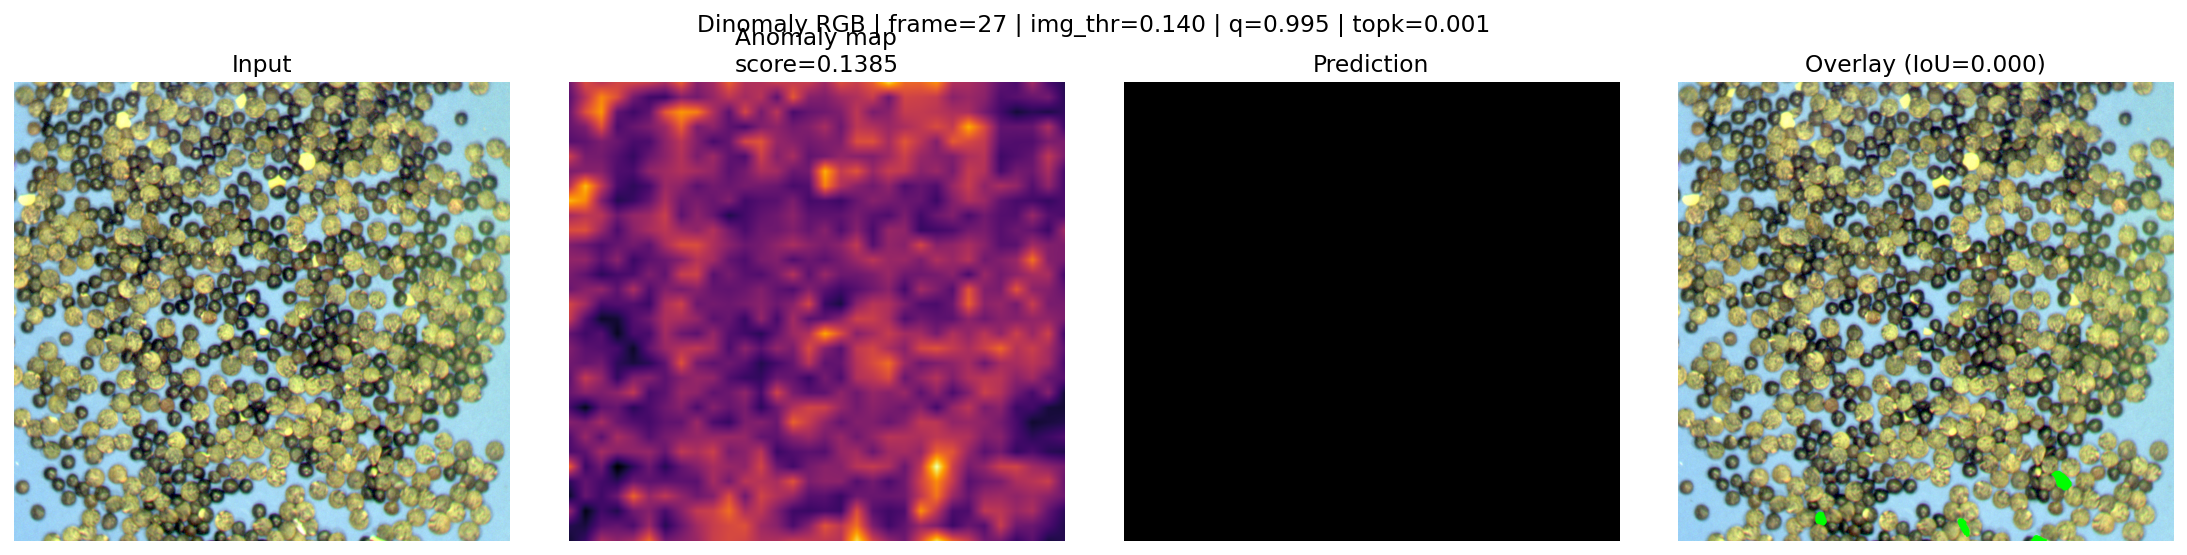

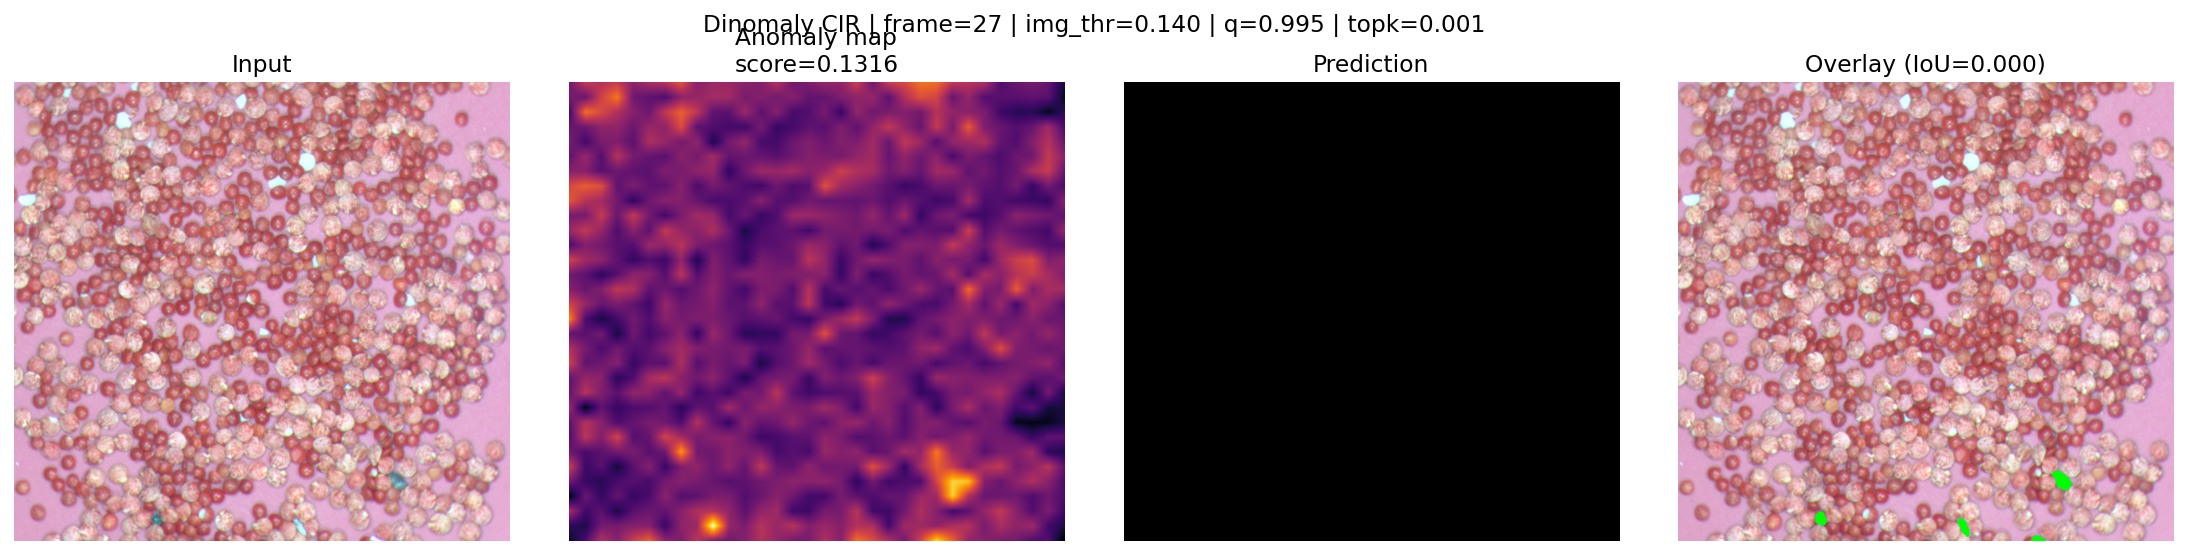

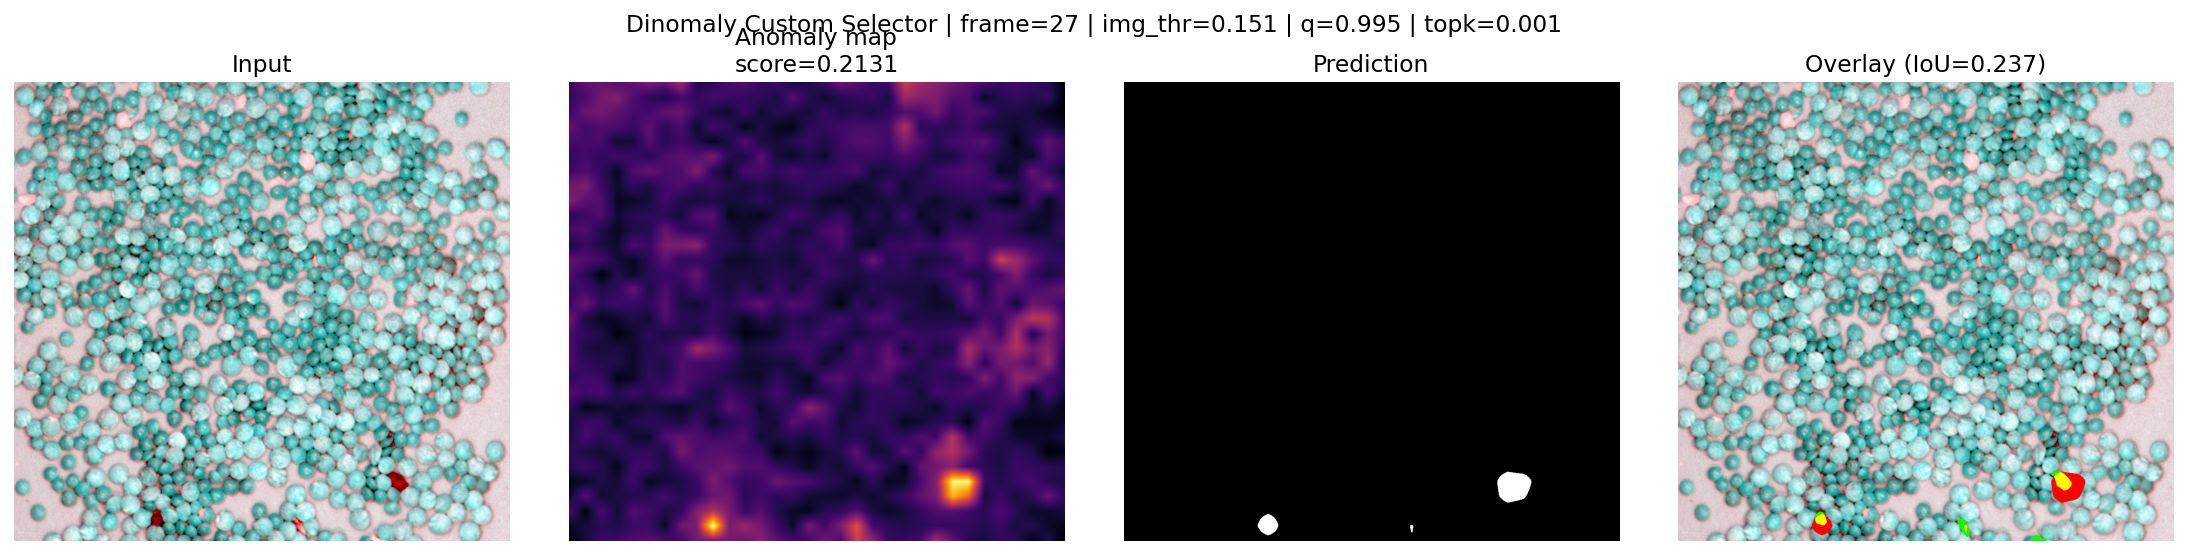

In [10]:
for method in config["methods"]:
    row = next(
        (r for r in preview_results[method.name] if int(r["frame_idx"]) == PREVIEW_FRAME_ID),
        preview_results[method.name][0],
    )
    render_method_triplet(
        row,
        title=(
            f"{method.title} | frame={row['frame_idx']} | "
            f"img_thr={method.image_threshold:.3f} | q={method.quantile:.3f} | "
            f"topk={method.top_k_fraction:g}"
        ),
    )
    plt.show()


## 8 · Export overlay videos for all frames

Now we render every frame at `VIDEO_FPS` for visual comparison. The notebook
reuses any video that already exists; otherwise it regenerates it from the
live pipeline.

Primary writer: `ToVideoNode`. Fallback writer: OpenCV AVI writer if MP4 fails.


In [11]:
expected_video_paths = {
    m.name: output_dir / f"{m.name}_overlay_4fps.mp4"
    for m in config["methods"]
}

missing = [name for name, path in expected_video_paths.items() if not path.exists()]
print("Existing videos:")
for name, path in expected_video_paths.items():
    print(f"- {METHOD_TITLES[name]}: {path} | exists={path.exists()}")

if missing and RUN_VIDEO_EXPORT_IF_MISSING:
    print("\nMissing videos will be generated:", missing)
    all_frame_indices = set(range(len(dm.predict_ds)))
    full_results = {}
    for method in config["methods"]:
        if method.name not in missing:
            continue
        print(f"Full inference for {method.title} ...")
        pipe = load_pipeline_for_inference(
            yaml_path=method.yaml_path,
            pt_path=method.pt_path,
            plugins_manifest=config["plugins_manifest"],
            device=str(device),
        )
        full_results[method.name] = run_method_on_frame_subset(
            pipeline=pipe,
            loader=loader,
            frame_indices=all_frame_indices,
            image_threshold=method.image_threshold,
            quantile=method.quantile,
            top_k_fraction=method.top_k_fraction,
            device=device,
            normal_class_ids=NORMAL_CLASS_IDS,
        )

    for method in config["methods"]:
        if method.name not in missing:
            continue
        path = export_overlay_video(
            rows=full_results[method.name],
            output_path=expected_video_paths[method.name],
            fps=VIDEO_FPS,
            overlay_title=(
                f"{method.title} | thr={method.image_threshold:.3f} "
                f"q={method.quantile:.3f} topk={method.top_k_fraction:g}"
            ),
        )
        expected_video_paths[method.name] = path
elif missing:
    print("\nSome videos are missing. Set RUN_VIDEO_EXPORT_IF_MISSING=True to generate them.")


Existing videos:
- Dinomaly RGB: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_rgb_overlay_4fps.mp4 | exists=False
- Dinomaly CIR: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_cir_overlay_4fps.mp4 | exists=False
- Dinomaly Custom Selector: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_concrete_overlay_4fps.mp4 | exists=False

Missing videos will be generated: ['dinomaly_rgb', 'dinomaly_cir', 'dinomaly_concrete']
Full inference for Dinomaly RGB ...


2026-05-06 14:36:10.898 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_git_plugin:519 - Using cached plugin 'dinomaly' at C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3


2026-05-06 14:36:10.898 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 9 dependencies from C:\Users\anish.raj\.cuvis_plugins\dinomaly@v0.1.3\pyproject.toml


2026-05-06 14:36:10.898 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 9 dependencies for plugin 'dinomaly'...


2026-05-06 14:36:10.898 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai>=0.1.0, cuvis-ai-core>=0.1.0, anomalib==2.1.0, kornia==0.6.12, numpy>=1.20.0, opencv-python>=4.8.0, tqdm>=4.66.0, defusedxml>=0.7.1, open-clip-torch>=2.24.0


...

2026-05-06 14:38:04.282 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:138 - TwoStageDecider[batch=0]: k=1080, topk_min=0.176245, topk_max=0.209350, image_score=0.187179


2026-05-06 14:38:04.282 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:156 - TwoStageDecider: image_score=0.187179 >= threshold=0.151000, applying quantile thresholding (q=0.995)


2026-05-06 14:38:04.856 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:111 - TwoStageDecider input: shape=torch.Size([1, 1000, 1080, 1]), device=cuda:0, dtype=torch.float32, min=0.042139, max=0.207790, mean=0.069051


2026-05-06 14:38:04.856 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:138 - TwoStageDecider[batch=0]: k=1080, topk_min=0.176024, topk_max=0.207790, image_score=0.186643


2026-05-06 14:38:04.856 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:156 - TwoStageDecider: image_score=0.186643 >= threshold=0.151000, applying quantile thresholding (q=0.995)


## 9 · Watch the method videos

These videos make the comparison easiest to understand in a meeting or tutorial:

- RGB: baseline visible view (when its HF assets are uploaded).
- CIR: near-infrared material contrast (when its HF assets are uploaded).
- Custom selector: task-selected bands from the frozen-AdaCLIP selector experiment.

If inline display fails in a remote browser, use the printed file paths and
open or download the MP4 files.


In [12]:
for method in config["methods"]:
    path = expected_video_paths[method.name]
    print(f"\n{method.title}: {path}")
    if path.exists():
        display(Video(filename=str(path), embed=IN_COLAB, width=720, html_attributes="controls loop"))
    else:
        print("Missing video file.")



Dinomaly RGB: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_rgb_overlay_4fps.avi



Dinomaly CIR: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_cir_overlay_4fps.avi



Dinomaly Custom Selector: D:\cuvis-ai\notebooks\use_cases\outputs\Auto_003+01\dinomaly_concrete_overlay_4fps.avi


## 10 · Takeaways

For this lentils use case the headline lesson is that **channel choice
matters**. The detector architecture stays fixed; only the hyperspectral-to-
3-channel projection changes what material contrasts the model can see.

The notebook is method-extensible: when the RGB and CIR full pipelines land on
HuggingFace under their `dinomaly_*_full_pipeline/` subfolders, this same
notebook will pick them up automatically (no code changes needed) and the
video grid will fill out to three side-by-side comparisons.
